In [1]:
using PhDProject
using JLD2
using ITensors
using Plots
using ProgressMeter
using LinearAlgebra
using SparseArrays
using Kronecker

# functions used in this script that have been edited from src
# - propagate_correlations 
# - matrix_operators
# - calculate_ρ_using_G
# - spectral function
# - chain_mapping_coeffs
# - initialise_setup
# -

# functions used in this script that are taken from src
# - ρ_to_Λ
# - spin operators
# - JW_string_mat
# -

#functions that I'm no longer using 
# - ancilla_phase_gate_swap (from Mpemba functions)
# - calculate_ρ_using_G


In [15]:
function propagate_correlations(Ci,H_single,times)
    """
    The correlation matrix C_ij = expect(cdag[j]*c[i]) propagates according to
    C_ij(t) =U*C_ij(0)*U', but G_ij = expect(cdag[i]*c[j]) doesn't.This is why 
    the correlation matrices are transposed before calculating the reduced density
    matrix as the formula uses the second definition.
    """
    δt = times[2] - times[1]
    
   
    U_step = exp(-im*δt*H_single)

    corrs = Vector{Any}(undef,length(times))
    corrs[1] = U_step*Ci*U_step'
    for i in 2:length(times)
        corrs[i] = U_step*corrs[i-1]*U_step'
    end
    return corrs
end
function matrix_operators(M)

    Sz,Sp,Sm,_ = spin_operators(M)
    cdag_mat = Vector{Any}(undef,M)
    c_mat = Vector{Any}(undef,M)

    for n=1:M
        #Build JW_string
        Z = JW_string_mat(Sz,n,M)
        cdag_mat[n] = Z*Sm[n]
        c_mat[n]  = Z*Sp[n]
    end
    return cdag_mat,c_mat
   
end
function spectral_function(w,spec_fun_type,thermal_chain_number,Γ,β,μ,D)


    f = 1 ./(exp.(β*(w .- μ)).+ 1)
    if thermal_chain_number == 1
        renorm = 1 .- f
    elseif thermal_chain_number == 2
        renorm = f
    end

    if spec_fun_type == "box"
        ρ = (1/(2*D))*(heaviside(w .+ D) .- heaviside(w .- D)).*renorm
        J =  (Γ*D/π)*ρ
    elseif spec_fun_type =="ellipse"
        ρ = real((2/(π*D))*sqrt.(Complex.(1 .-(w/D).^2)).*renorm)
        J =  (Γ*D/π)*ρ
    end
    replace_nan(J)
    return J
end
function chain_mapping_coeffs(spec_fun_type,thermal_chain_number,N_bath,Γ,β,μ,D;kwargs...)

    N_chain = get(kwargs,:N_chain,N_bath)
    @assert(N_chain <= N_bath)

    couplings,energies = complex(zeros(N_bath)),complex(zeros(N_bath))
    spec_fun(w) = spectral_function(w,spec_fun_type,thermal_chain_number,Γ,β,μ,D)
    supp = (-D,D)
    my_meas = PhDProject.Measure("my_meas", spec_fun, supp, false, Dict())
    my_op = PhDProject.OrthoPoly("my_op", N_chain-1, my_meas; Nquad=100000);
    α_coeffs,β_coeffs = PhDProject.coeffs(my_op)[:,1],PhDProject.coeffs(my_op)[:,2]
        

    if length(α_coeffs)<N_bath
        energies[1:N_chain] = α_coeffs
        couplings[1:N_chain] = sqrt.(β_coeffs)
        energies[N_chain+1:end] .= α_coeffs[N_chain]
        couplings[N_chain+1:end] .= sqrt(β_coeffs[N_chain])
    else
        energies = α_coeffs
        couplings = sqrt.(β_coeffs)
    end
    return energies,couplings
end
function initialise_setup(N_ring,J,B,compute_maps_bool,N_bath,spec_fun_type,Γ,β,μ,D;kwargs...)


    if compute_maps_bool ==true
        qS = 1:N_ring
        qA = N_ring+1:2*N_ring
        # qS = 1:2:2*N_ring
        # qA = 2:2:2*N_ring
        q = 1:2*N_ring
        qbath_full = 2*N_ring+1:2:2*(N_ring+N_bath)
        qbath_empty = 2*N_ring+2:2:2*(N_ring+N_bath)
    else
        qS = 1:N_ring
        qA = 0:0
        q = qS
        qbath_full = N_ring+1:2:N_ring+2*N_bath
        qbath_empty = N_ring+2:2:N_ring+2*N_bath
        init_occ_vec = get(kwargs,:init_occ_vec,0.5*ones(N_ring))
    end

    #Creating chain coefficients
    energies_full,couplings_full = chain_mapping_coeffs(spec_fun_type,1,N_bath,Γ,β,μ,D;kwargs...)
    energies_empty,couplings_empty = chain_mapping_coeffs(spec_fun_type,2,N_bath,Γ,β,μ,D;kwargs...)

    #Build single particle hamiltonian
    if compute_maps_bool == true
        H_single = complex(zeros(2*N_ring+2*N_bath,2*N_ring+2*N_bath))
    else
        H_single = complex(zeros(N_ring+2*N_bath,N_ring+2*N_bath))
    end


    #Create system hamiltonian terms
    for i =1:N_ring
        H_single[qS[i],qS[i]] = -2*B
        if i <N_ring
            H_single[qS[i+1],qS[i]] = -2*J
            H_single[qS[i],qS[i+1]] = -2*J
        elseif i!= 1
            @assert(i==N_ring)
            H_single[qS[1],qS[i]] = -2*J
            H_single[qS[i],qS[1]] = -2*J
        end
    end

    #create system bath coupling terms
    H_single[qS[end],qbath_full[1]] = couplings_full[1]
    H_single[qbath_full[1],qS[end]] = conj(couplings_full[1])

    H_single[qS[end],qbath_empty[1]] = couplings_empty[1]
    H_single[qbath_empty[1],qS[end]] = conj(couplings_empty[1])

    #create bath terms
    for i=1:N_bath
        H_single[qbath_full[i],qbath_full[i]] = energies_full[i]
        H_single[qbath_empty[i],qbath_empty[i]] = energies_empty[i]
        if i < N_bath
            H_single[qbath_full[i],qbath_full[i+1]] = couplings_full[i+1]
            H_single[qbath_full[i+1],qbath_full[i]] = conj(couplings_full[i+1])

            H_single[qbath_empty[i],qbath_empty[i+1]] = couplings_empty[i+1]
            H_single[qbath_empty[i+1],qbath_empty[i]] = conj(couplings_empty[i+1])
        end
    end

    #create initial correlation matrix
    Ci = complex(zeros(size(H_single)))
    @show(qbath_full)
    [Ci[i,i] = 1 for i in qbath_full]

    if compute_maps_bool == true
        for i =1:N_ring 
            Ci[qS[i],qS[i]] = 0.5
            Ci[qS[i],qA[i]] = 0.5
            Ci[qA[i],qS[i]] = 0.5
            Ci[qA[i],qA[i]] = 0.5
        end
    else
        for i =1:N_ring 
            Ci[qS[i],qS[i]] = init_occ_vec[i]
        end
    end
    return Ci,H_single,q,qA,qS
end
function calculate_ρ_from_correlation_matrix(C, mode_subset; eps=1e-14,kwargs...)
    """
        gaussian_rdm_density_matrix(C, mode_subset,qA; eps=1e-14)

    Construct the fermionic Gaussian density matrix

        ρ = ⊗ₖ [(1-νₖ)|0><0| + νₖ|1><1|]

    from the correlation matrix C restricted to the mode_subset modes.

    Arguments
    ---------
    C            : correlation matrix
    mode_subset  : modes to calculate rdm
    qA           : ancilla modes

    Returns
    -------
    ρ      : Dense many-body density matrix
    """

    N = length(mode_subset)
    ddag,d = matrix_operators(N)
    dim = size(ddag[1],1)

    #take the subset and symmetrize
    C = transpose(C[mode_subset,mode_subset])
    C = (C + C') / 2

    # 2. Diagonalize correlation matrix
    eig = eigen(Hermitian(C))
    ν = clamp.(real(eig.values), eps, 1-eps)
    U = eig.vectors

    # Construct rotated fermion operators
    #    f_k = Σ_i U†_{ki} d_i
    f = Vector{Any}(undef, N)
    fdag = Vector{Any}(undef, N)

    for k in 1:N
        fk = zero(d[1])
        for i in 1:N
            fk += conj(U[i,k]) * d[i]
        end
        f[k] = fk
        fdag[k] = fk'
    end

    # Construct many-body density matrix
    #    ρ = Π_k [(1-ν_k)(1-n_k) + ν_k n_k]
    # where n_k = f†_k f_k

    ρ = Matrix(I, dim, dim)
    for k in 1:N
        nk = fdag[k] * f[k]
        ρk = (1-ν[k]) * (Matrix(I, dim, dim) - nk) +
              ν[k] * nk
        ρ *= ρk
    end

    ##checks it's a valid density matrix up to a tolerance 1e-5
    ρ_test(ρ,1e-5) 

    return ρ
end
function calculate_Λ_from_correlation_matrix(C, mode_subset,qA; eps=1e-14,kwargs...)
    """
        gaussian_rdm_density_matrix(C, mode_subset,qA; eps=1e-14)

    Construct the fermionic Gaussian density matrix

        ρ = ⊗ₖ [(1-νₖ)|0><0| + νₖ|1><1|]

    from the correlation matrix C restricted to the mode_subset modes.

    Arguments
    ---------
    C            : correlation matrix
    mode_subset  : modes to calculate rdm
    qA           : ancilla modes

    Returns
    -------
    ρ      : Dense many-body density matrix
    """

    symmetry_subspace = get(kwargs,:symmetry_subspace, "Number conserving")
    N = length(mode_subset)
    ddag,d = matrix_operators(N)
    dim = size(ddag[1],1)

    #take the subset and symmetrize
    C = transpose(C[mode_subset,mode_subset])
    C = (C + C') / 2


    # 2. Diagonalize correlation matrix
    eig = eigen(Hermitian(C))
    ν = clamp.(real(eig.values), eps, 1-eps)
    U = eig.vectors

    # Construct rotated fermion operators
    #    f_k = Σ_i U†_{ki} d_i
    f = Vector{Any}(undef, N)
    fdag = Vector{Any}(undef, N)

    for k in 1:N
        fk = zero(d[1])
        for i in 1:N
            fk += conj(U[i,k]) * d[i]
        end
        f[k] = fk
        fdag[k] = fk'
    end

    # Construct many-body density matrix
    #    ρ = Π_k [(1-ν_k)(1-n_k) + ν_k n_k]
    # where n_k = f†_k f_k

    ρ = Matrix(I, dim, dim)
    for k in 1:N
        nk = fdag[k] * f[k]
        ρk = (1-ν[k]) * (Matrix(I, dim, dim) - nk) +
              ν[k] * nk

        ρ *= ρk
    end

    # gates =  ancilla_phase_gate_swap(qA,ddag,d)
    # ρ = apply_gates_to_ρmat(ρ,gates)

    ##PH transform
    for index in qA
  #      gate = Sp[index] + Sm[index]
        gate = ddag[index] +d[index]#+ ((-1)^(N_ring))*c_mat[index]
        ρ = gate*ρ*gate'
    end

    ##checks it's a valid density matrix up to a tolerance 1e-5
    ρ_test(ρ,1e-5) 

    ##reshape to give the map
    Λ = ρ_to_Λ(ρ,N_ring) 
    if symmetry_subspace =="Number conserving"
        qN = extract_physical_modes(N_ring)
        Λ = Λ[qN,qN]
    end

    return Λ
end


calculate_Λ_from_correlation_matrix (generic function with 1 method)

qbath_full = 9:2:207
Correlation matrix propagator


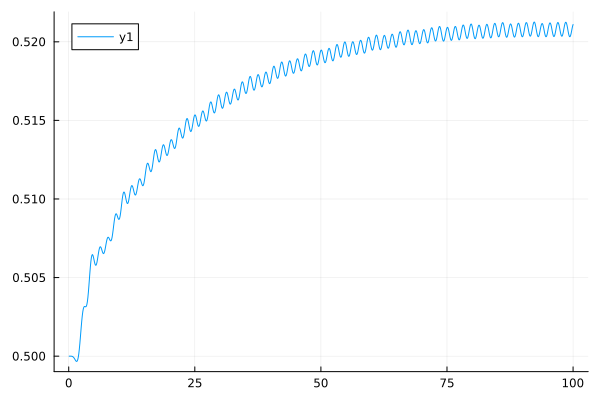

Calculating Λ(t) from the single particle correlation matrix.


Progress:  99%|█████████████████████████████████████████|  ETA: 0:00:03mProgress:  14%|██████                                   |  ETA: 0:03:08██████████████████                   |  ETA: 0:01:41%|██████████████████████████               |  ETA: 0:01:19ess:  66%|████████████████████████████             |  ETA: 0:01:13ess:  68%|████████████████████████████             |  ETA: 0:01:10████████████████████████████             |  ETA: 0:01:10Progress:  69%|█████████████████████████████            |  ETA: 0:01:09mProgress:  71%|██████████████████████████████           |  ETA: 0:01:04m

In [ ]:
#spin ring parameters
N_ring = 4
J = 0.5
B = 0.5   
compute_maps_bool = true
init_occ_vec = [0.2,0.8,0.1]

#Chain mapping parameters
N_bath = 100
N_chain = 100
β = 1000
μ = 0
Γ = 0.1
D = 1
spec_fun_type = "ellipse"

#evolution parameters
δt = 0.1
T = 100
times = range(δt,stop=T,step=δt)

Ci,H_single,q,qA,qS = initialise_setup(N_ring,J,B,compute_maps_bool,N_bath,spec_fun_type,Γ,β,μ,D;N_chain,init_occ_vec)
heatmap(real.(H_single))

println("Correlation matrix propagator")
corrs = propagate_correlations(Ci,H_single,times)
den = [corr[1,1] for corr in corrs]
display(Plots.plot(times,real.(den)))

if compute_maps_bool == true
    Λ_vec = similar(corrs)
    L_vec = Vector{Any}(undef,length(times)-2)
    println("Calculating Λ(t) from the single particle correlation matrix.")
    @showprogress for i =1:length(corrs)
        Λ_vec[i] = calculate_Λ_from_correlation_matrix(corrs[i], q,qA; eps=1e-14)
        if i>2
            L = (Λ_vec[i] - Λ_vec[i-2])/(2*δt)
            L = L * pinv(Λ_vec[i-1])
            L_vec[i-2] = L
        end
    end

    #map check
    ρi = calculate_ρ_from_correlation_matrix(Ci,qS; eps=1e-14)
    ρ_evolved = calculate_ρ_from_correlation_matrix(corrs[end],qS; eps=1e-14)
    @show(norm(expand_Λ(Λ_vec[end],N_ring)*vectorise_mat(ρi)-vectorise_mat(ρ_evolved)))

    spectra_Λ = complex(zeros(length(Λ_vec),size(Λ_vec[1])[1]))
    @showprogress for i =1:length(corrs)
        spectra_Λ[i,:] = eigen(Λ_vec[i]).values   
    end
    display(Plots.plot(times,real.(spectra_Λ),label=false))

    spectra_L = complex(zeros(length(L_vec),size(Λ_vec[1])[1]))
    [spectra_L[i,:] = eigen(L_vec[i]).values for i=1:length(L_vec)] 
    display(Plots.plot(times[2:end-1],real.(spectra_L),ms=0.1,label=false))
end

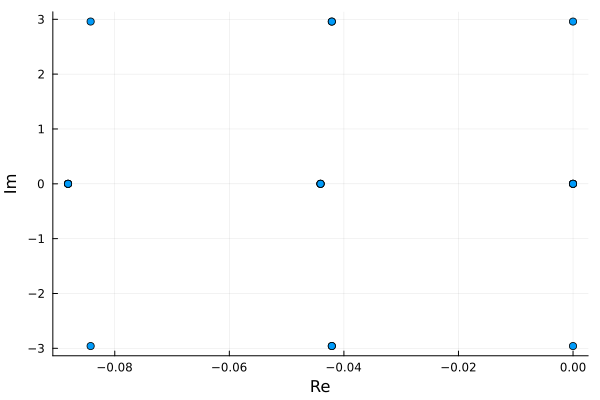

In [40]:
display(Plots.scatter(real.(spectra_L[end,:]),imag.(spectra_L[end,:]),xlabel = "Re",
    ylabel = "Im",
    label = "",
))

# display(PhDProject.Plots.scatter(real.(spectra_Λ[200,:]),imag.(spectra_Λ[end,:]),xlabel = "Re",
#     ylabel = "Im",
#     label = "",
# ))

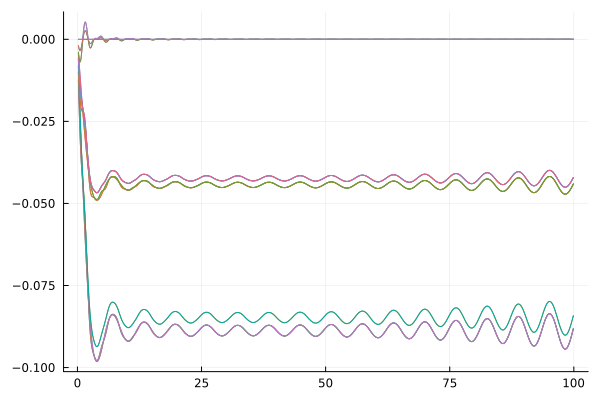

In [43]:
display(Plots.plot(times[2:end-1],real.(spectra_L),ms=0.1,label=false))

[ Info: Saved animation to c:\Users\mf22297\OneDrive - University of Bristol\Documents\Cleaned-PhD-repository\notebooks\Spin ring\propagator spectrum.gif


Plots.AnimatedGif("c:\\Users\\mf22297\\OneDrive - University of Bristol\\Documents\\Cleaned-PhD-repository\\notebooks\\Spin ring\\propagator spectrum.gif")
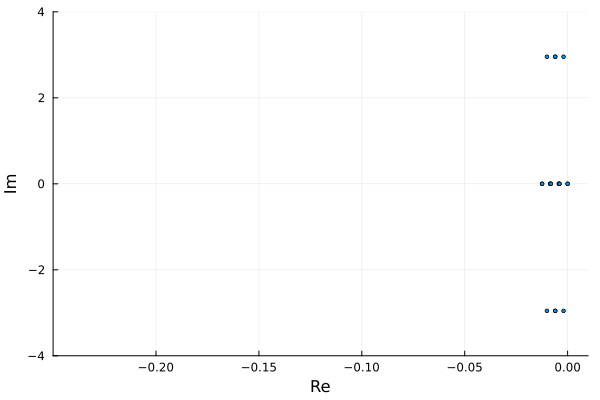

In [42]:

# anim = @animate for i=1:length(times)
#     Plots.scatter(real.(spectra_Λ[i,:]),imag.(spectra_Λ[i,:]),
#     xlim=(-1,1),ylim=(-1,1),
#     xlabel = "Re",
#     ylabel = "Im",label = "",ms=2)
# end
# gif(anim,"map spectrum.gif")


anim = @animate for i=1:length(times)-2
    Plots.scatter(real.(spectra_L[i,:]),imag.(spectra_L[i,:]),
    xlim=(-0.25,0.01),ylim=(-4,4),
    xlabel = "Re",
    ylabel = "Im",label = "",ms=2)
end
gif(anim,"propagator spectrum.gif")